In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Dropout,Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.preprocessing import image

In [30]:
train_dir='brain_tumor_dataset/'

In [31]:
#image processing
train_gen=ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=.2,
    zoom_range=20,
    horizontal_flip=True)

In [32]:
# load image from directory with batches and gives label
train_data=train_gen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training')

val_data=train_gen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation')

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [33]:
print("label:",train_data.class_indices)

label: {'no': 0, 'yes': 1}


In [34]:
model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid') 
])

In [35]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [40]:
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    "best_model.keras",             
    monitor = 'val_accuracy',       
    save_best_only = True          
)

In [ ]:
# Train the model
history = model.fit(
    train_data,                          
    epochs = 15,                           
    validation_data = val_data,            

    steps_per_epoch = len(train_data),     
    validation_steps = len(val_data),      

    callbacks = [early_stop, checkpoint]   
)

Epoch 1/15
1/7 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.6250 - loss: 1.6717

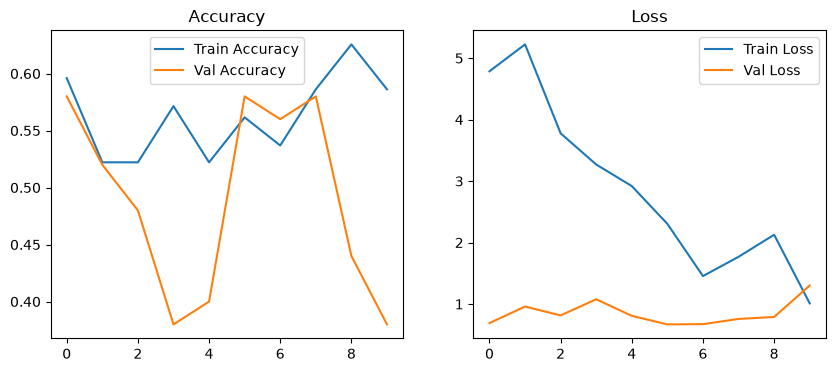

In [11]:

plt.figure(figsize=(10,4))

# Plot accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')       # Training accuracy
plt.plot(history.history['val_accuracy'], label='Val Accuracy')     # Validation accuracy
plt.title("Accuracy")
plt.legend()

# Plot loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')               # Training loss
plt.plot(history.history['val_loss'], label='Val Loss')             # Validation loss
plt.title("Loss")
plt.legend()

plt.show()

In [12]:
img_path = 'Y1.jpg' 
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Raw Prediction:", prediction)
if prediction[0][0] > 0.5:
    print("YES you brain_tumor")
else:
    print("NO have brain tumor")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step
Raw Prediction: [[0.678882]]
YES you brain_tumor


In [13]:
model.save("brain_final.keras")

In [14]:
import tensorflow as tf
from tensorflow.keras.models import load_model


In [15]:
model=load_model("brain_final.keras")

In [20]:
converter=tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimization=[tf.lite.Optimize.DEFAULT]
tflite_model=convertor.convert()

INFO:tensorflow:Assets written to: C:\Users\bhakti\AppData\Local\Temp\tmph16luivc\assets


INFO:tensorflow:Assets written to: C:\Users\bhakti\AppData\Local\Temp\tmph16luivc\assets


Saved artifact at 'C:\Users\bhakti\AppData\Local\Temp\tmph16luivc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2214990167696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2215088359568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2215088369552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2215088359760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2215088359376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2215088369168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2215090165840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2215090167760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2215090169872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2215090167952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  22150

In [21]:
with open("brain_final.tflite","wb") as f:
    f.write(tflite_model)

In [22]:
import os 
size=os.path.getsize("brain_final.tflite")/(1024*1024)
print(size)

12.615093231201172
